In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
plt.rc('font', family='Malgun Gothic')  # Windows
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

In [3]:
for_c_chart = pd.read_csv("../B1_data/preprocessing_data/for_c_chart.csv")
for_c_chart['c_path'] = for_c_chart['c_path'].astype(str)
for_c_chart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Target    14816 non-null  int64 
 1   Datetime  14816 non-null  object
 2   c_path    14816 non-null  object
dtypes: int64(1), object(2)
memory usage: 347.4+ KB


In [4]:
def draw_c_chart(df, c_path_num, date_range):
    df_max = df.copy() #df.groupby('Datetime', as_index=False)['Target'].max()  # max값만 남김
    
    mean_val = df['Target'].mean()
    sigma = math.sqrt(mean_val)

    ucl = mean_val + 3 * sigma
    lcl = mean_val - 3 * sigma
    count = len(df_max[(df_max['Target'] > ucl) | (df_max['Target'] <lcl)])
    ratio = count/len(df_max)
    print("불량률", (df_max['Target'].sum()) / (df_max['Target'].count()* 520))
    print(mean_val, ucl, lcl, count, ratio)
    # 그래프 그리기
    plt.figure(figsize=(20, 5))
    plt.plot(df_max.index, df_max['Target'], color='black', marker='o', label='Target')
    plt.axhline(mean_val, color='green', linestyle='--', label='Mean')
    plt.axhline(ucl, color='red', linestyle='--', label='UCL (Mean + 3σ)') 
    plt.axhline(lcl, color='blue', linestyle='--', label='LCL (Mean - 3σ)') 
    #plt.axhline(195, color='yellow', linestyle='--', label='기준')
    plt.grid(False)
    #plt.xlim([date_range.min() - timedelta(days=5), date_range.max() + timedelta(days=5)]) # x축 범위
    
    plt.xlabel('날짜')
    plt.ylabel('Target(불량칩수)')
    plt.title('C Chart: ' + c_path_num + "(outer_rate:" + str(round(ratio,3)) + 
              ", 불량률:" +str(round((df_max['Target'].sum()) / (df_max['Target'].count()* 520),3)))
    plt.legend()
    plt.savefig("../B1_data/c_chart_graph/"+c_path_num+"_c_chart.png")
    plt.show()

In [5]:
for_c_chart['Datetime'] = pd.to_datetime(for_c_chart['Datetime'])
for_c_chart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Target    14816 non-null  int64         
 1   Datetime  14816 non-null  datetime64[ns]
 2   c_path    14816 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 347.4+ KB


불량률 0.17886834319526626
93.01153846153846 121.94428541294019 64.07879151013674 117 0.45


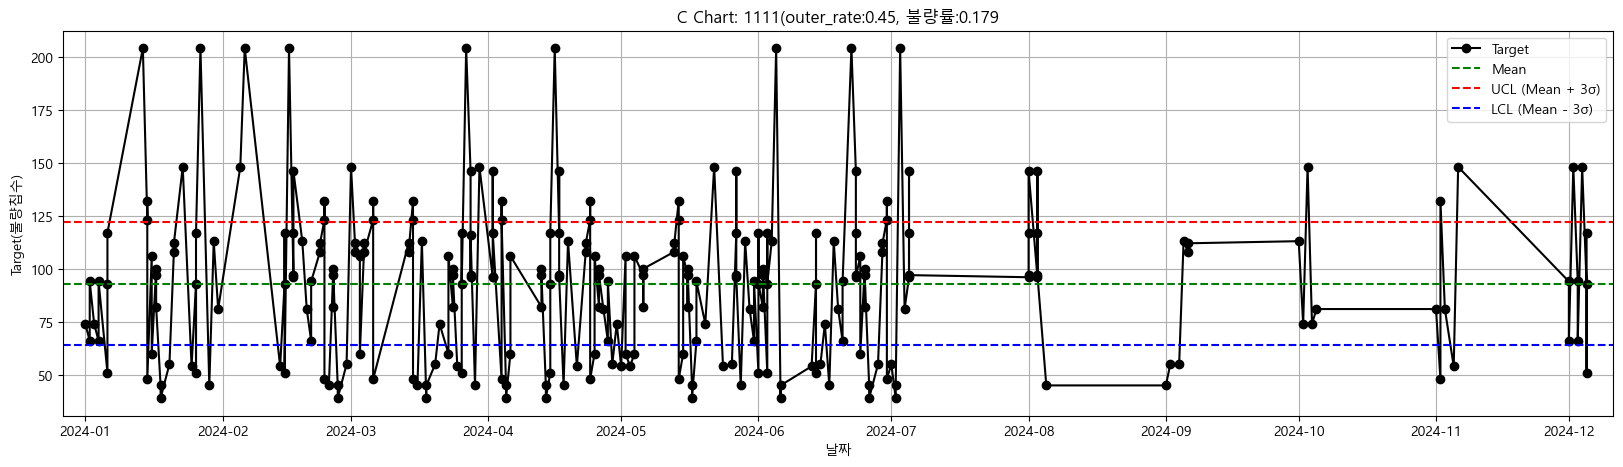

불량률 0.15796189791516893
82.14018691588785 109.32955399647636 54.950819835299335 54 0.5046728971962616


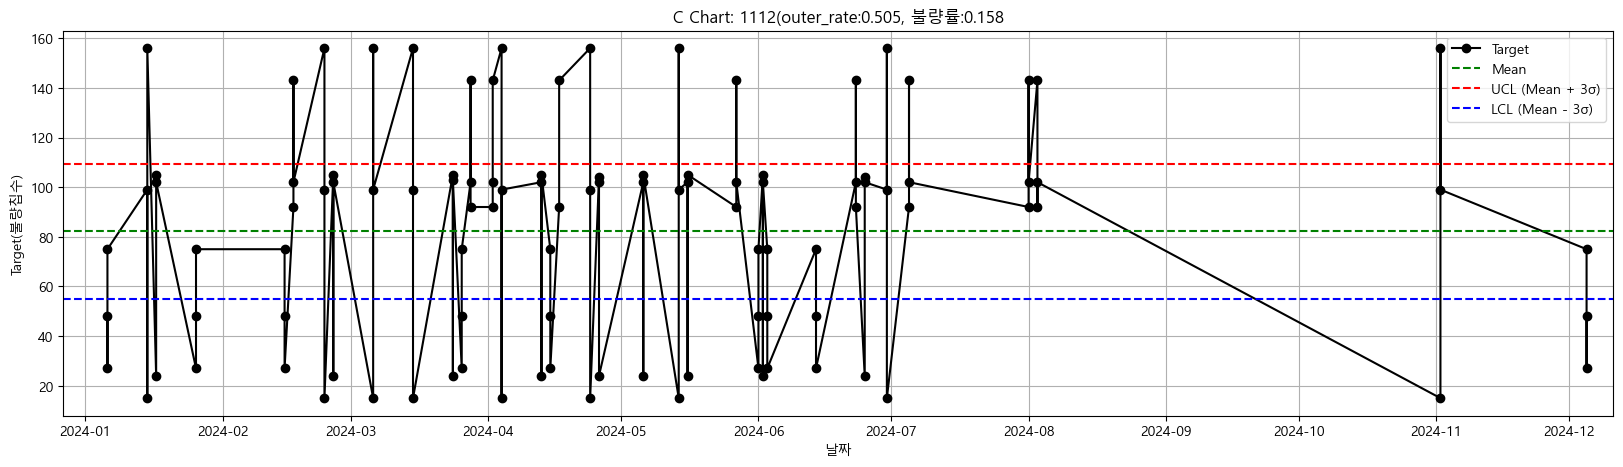

불량률 0.18497150997150996
96.18518518518519 125.60739901532834 66.76297135504204 122 0.5020576131687243


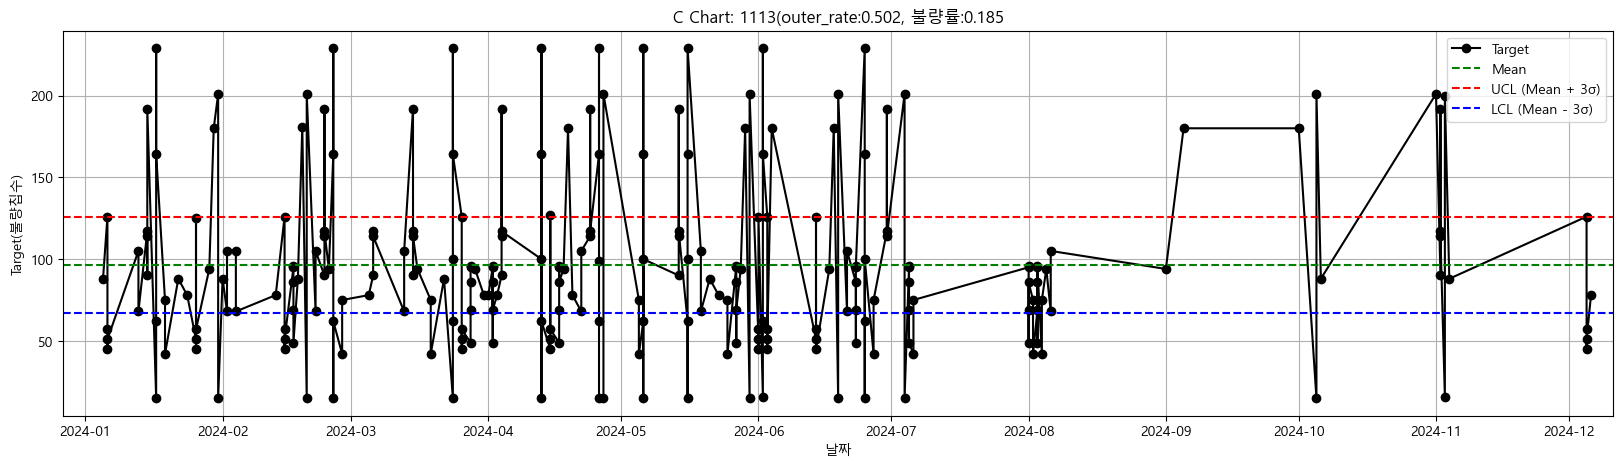

불량률 0.22863048166786484
118.88785046728972 151.5985620799344 86.17713885464505 53 0.4953271028037383


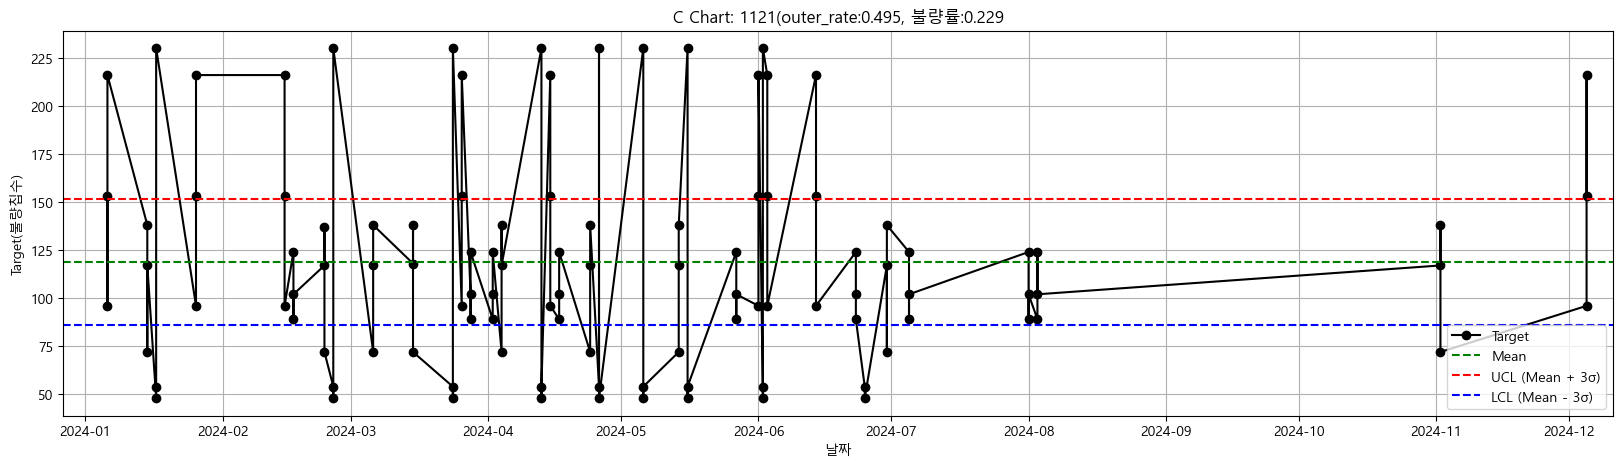

불량률 0.18189192092823378
94.58379888268156 123.76005960855483 65.4075381568083 154 0.4301675977653631


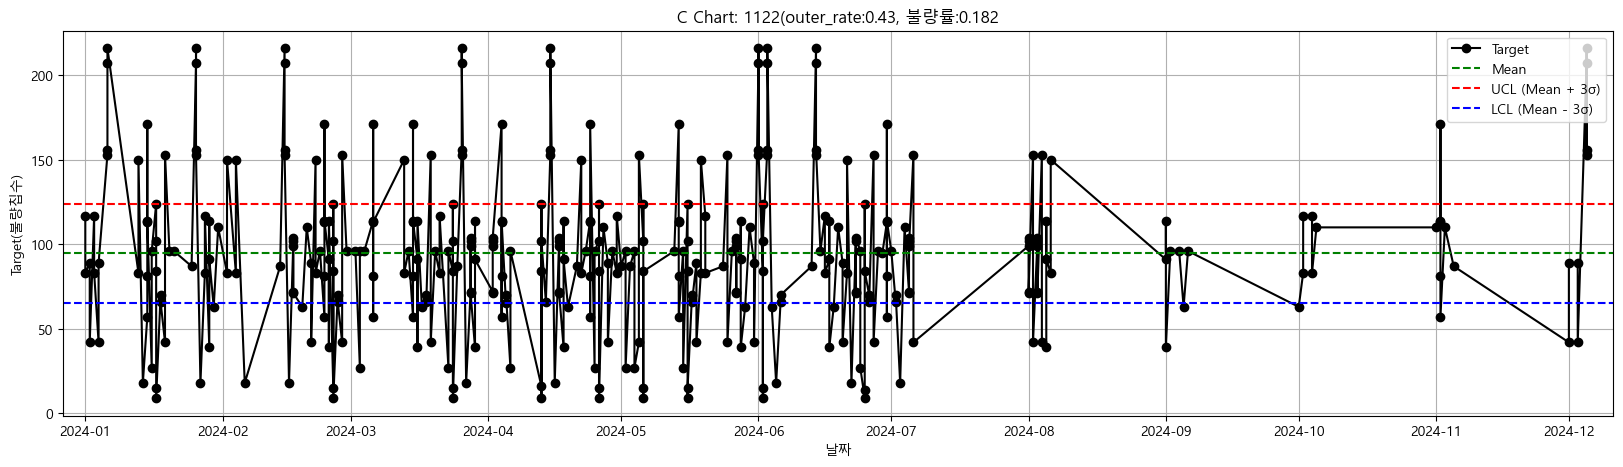

불량률 0.2885514018691589
150.0467289719626 186.79479777493052 113.2986601689947 35 0.32710280373831774


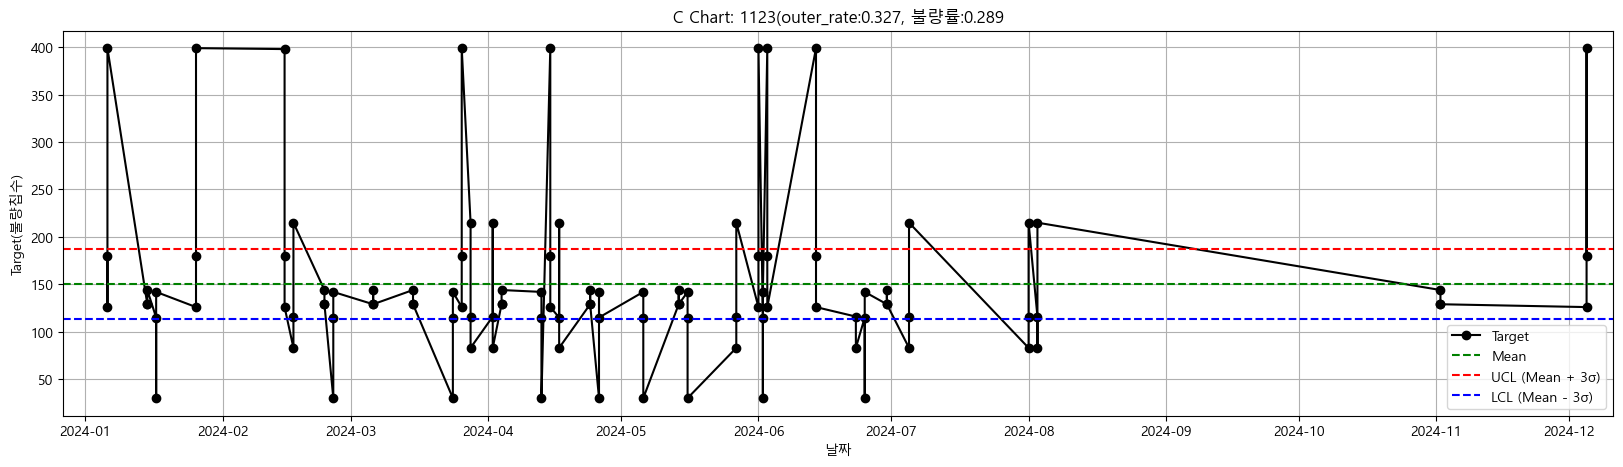

불량률 0.17659511031604055
91.82945736434108 120.57776368452402 63.08115104415815 116 0.4496124031007752


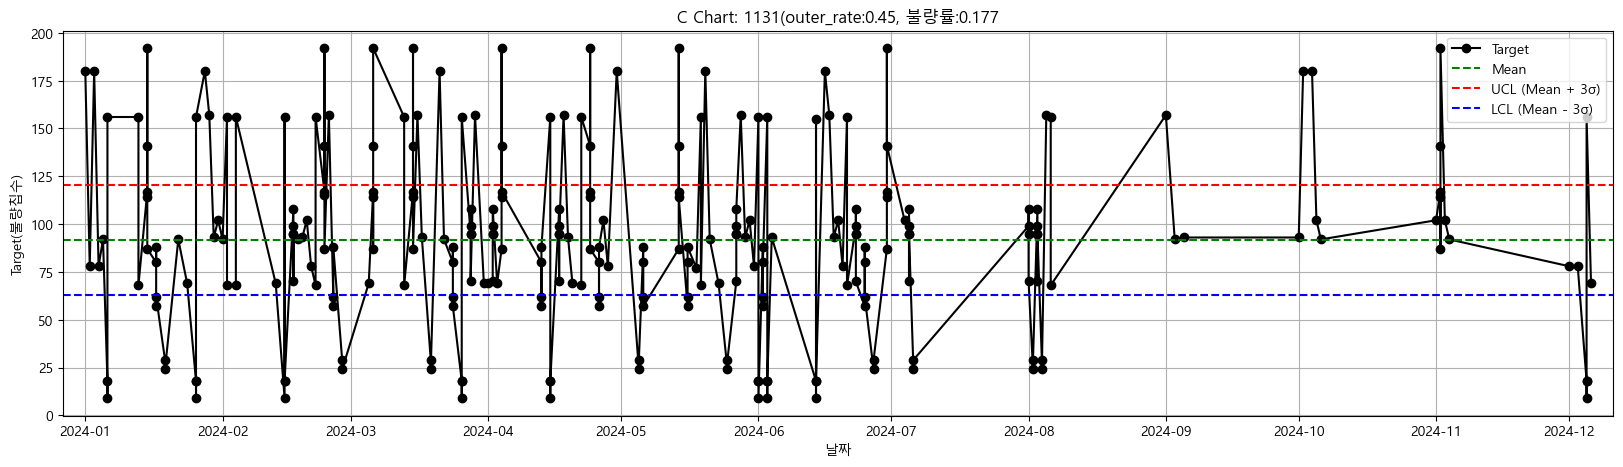

불량률 0.15627333831217327
81.2621359223301 108.30578995245278 54.21848189220742 53 0.5145631067961165



KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x00000283B4D6DA20> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



Error in callback <function flush_figures at 0x00000283B4D8FA30> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [6]:
date_list = for_c_chart['Datetime'].sort_values()
date_range = date_list.dt.date.unique()
c_path_list = sorted(for_c_chart['c_path'].unique())

for i, path in enumerate(c_path_list):
    c_path_df = for_c_chart[for_c_chart['c_path'] == path]
    c_path_df = c_path_df.sort_values(by = 'Datetime')
    #display(c_path_df)
    draw_c_chart(c_path_df, path, date_range)

In [ ]:
# 한개만 뽑기

path = '1111'

date_list = for_c_chart['Datetime'].sort_values()
date_range = date_list.dt.date.unique()
c_path_list = sorted(for_c_chart['c_path'].unique())

c_path_df = for_c_chart[for_c_chart['c_path'] == path]
c_path_df = c_path_df.sort_values(by = 'Datetime')
#display(c_path_df)
draw_c_chart(c_path_df, path, date_range)

In [18]:
def draw_c_chart_tail(df, c_path_num, date_range):
    df_max = df.copy() #df.groupby('Datetime', as_index=False)['Target'].max()  # max값만 남김
    
    mean_val = df['Target'].mean()
    sigma = math.sqrt(mean_val)

    ucl = mean_val + 3 * sigma
    lcl = mean_val - 3 * sigma
    count = len(df_max[(df_max['Target'] > ucl) | (df_max['Target'] <lcl)])
    ratio = count/len(df_max)
    print("불량률", (df_max['Target'].sum()) / (df_max['Target'].count()* 520))
    print(mean_val, ucl, lcl, count, ratio)
    # 그래프 그리기
    plt.figure(figsize=(12, 5))
    plt.plot(df_max.index, df_max['Target'], 
         color='orange', marker='o', markersize=8,  
         markerfacecolor='white', markeredgewidth=2,
         label='Target')
    plt.axhline(mean_val, color='green', linestyle='--', label='Mean')
    plt.axhline(ucl, color='red', linestyle='--', label='UCL (Mean + 3σ)') 
    plt.axhline(lcl, color='blue', linestyle='--', label='LCL (Mean - 3σ)') 
    #plt.axhline(195, color='yellow', linestyle='--', label='기준')
    plt.grid(False)
    #plt.xlim([date_range.min() - timedelta(days=5), date_range.max() + timedelta(days=5)]) # x축 범위
    plt.xticks(df_max.index[::5], df_max['Datetime'].dt.strftime('%Y-%m-%d')[::5])
    plt.xlabel('날짜')
    plt.ylabel('Target(불량칩수)')
    plt.title('C Chart: ' + c_path_num )
    plt.legend()
    plt.savefig("../B1_data/"+c_path_num+"_c_chart_for_figma.png")
    plt.show()

불량률 0.1576923076923077
82.0 109.16615541441226 54.83384458558775 6 0.2


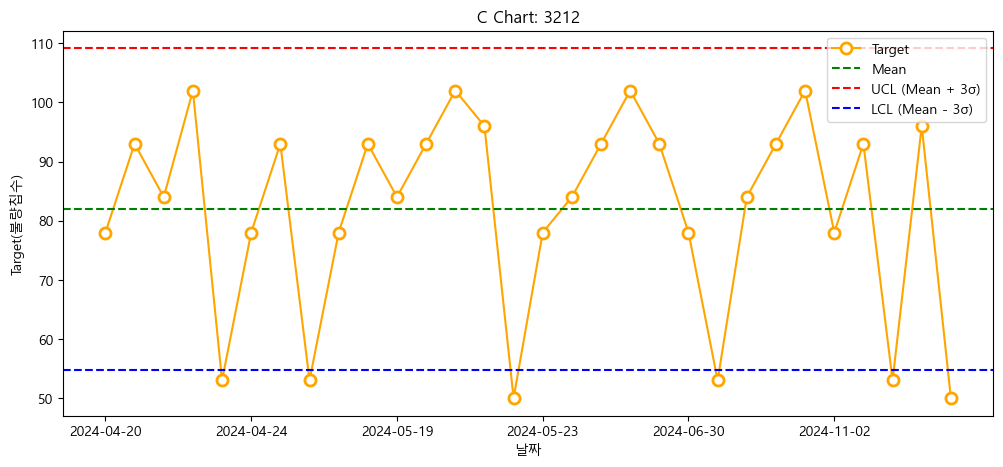

불량률 0.26314102564102565
136.83333333333334 171.92606762406652 101.74059904260017 20 0.6666666666666666


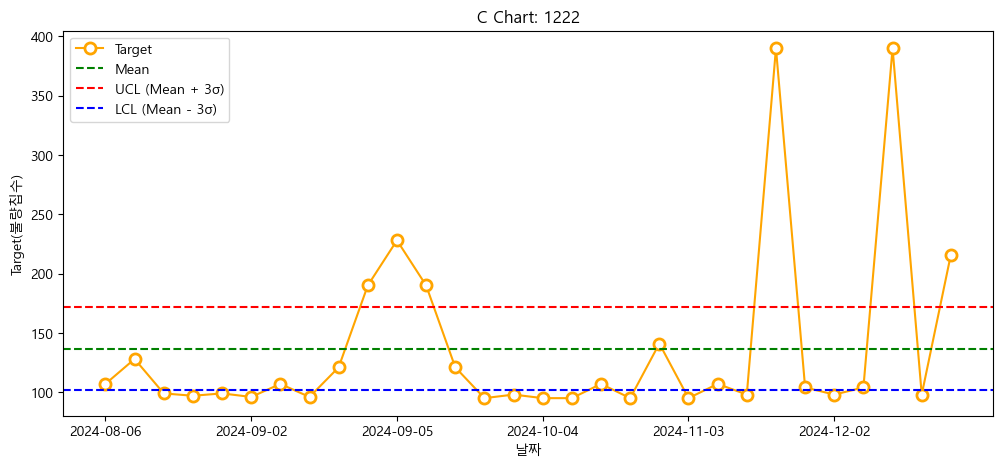

불량률 0.22012820512820513
114.46666666666667 146.56339547195148 82.36993786138186 7 0.23333333333333334


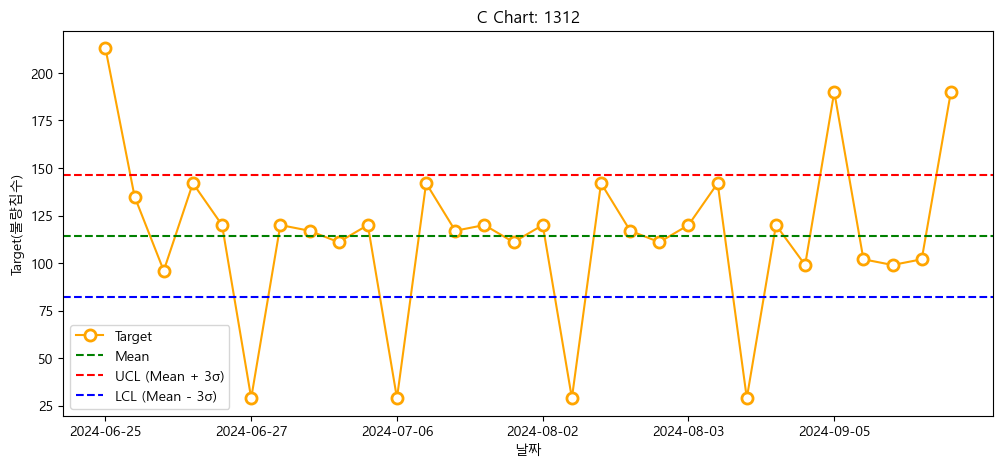

불량률 0.12352564102564102
64.23333333333333 88.2770435295572 40.18962313710946 8 0.26666666666666666


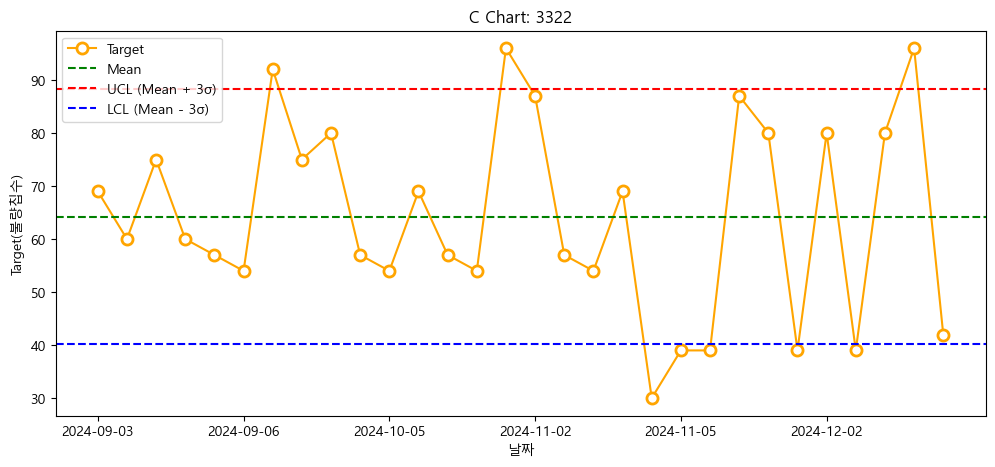

In [19]:
stable_list = ['3212', '1222', '1312', '3322']

for i in stable_list:
    path = i
    
    date_list = for_c_chart['Datetime'].sort_values()
    date_range = date_list.dt.date.unique()
    c_path_list = sorted(for_c_chart['c_path'].unique())
    
    c_path_df = for_c_chart[for_c_chart['c_path'] == path]
    c_path_df = c_path_df.sort_values(by = 'Datetime').reset_index(drop = True)
    draw_df = c_path_df.tail(30).reset_index(drop = True)
    #display(c_path_df)
    draw_c_chart_tail(draw_df, path, date_range)

In [13]:
for i in stable_list:
    path = i
    c_path_df = for_c_chart[for_c_chart['c_path'] == path][['Target','Datetime']]
    display(c_path_df.tail(20))

,Target,Datetime
11000,93,2024-05-14
11003,53,2024-05-14
11006,78,2024-05-14
11693,96,2024-05-23
11696,50,2024-05-23
11699,78,2024-05-23
12460,102,2024-08-06
12463,93,2024-08-06
12466,84,2024-08-06
12645,93,2024-03-06


,Target,Datetime
13665,99,2024-06-17
13668,97,2024-06-17
13811,190,2024-06-18
13844,228,2024-06-18
13932,95,2024-06-19
14034,104,2024-06-20
14044,390,2024-06-20
14140,107,2024-06-21
14275,144,2024-06-29
14377,141,2024-06-30


,Target,Datetime
12120,102,2024-05-29
12123,99,2024-05-29
12878,213,2024-05-06
12881,135,2024-05-06
12884,96,2024-05-06
13059,142,2024-07-06
13062,29,2024-07-06
13065,120,2024-07-06
13576,111,2024-06-23
13579,116,2024-06-23


,Target,Datetime
13838,75,2024-06-18
13940,57,2024-06-19
13962,54,2024-06-19
14028,39,2024-06-20
14168,81,2024-06-21
14209,60,2024-06-29
14212,57,2024-06-29
14215,54,2024-06-29
14236,92,2024-06-29
14338,96,2024-06-30
